**Goal:** stop hand-wiring weights and start *learning* them. You will build a multilayer
perceptron in **PyTorch**, train it with the explicit four-step loop (forward, loss, backward,
step), and watch it learn a curved decision boundary that a linear model cannot. Then you will
see **universal approximation** in action: a one-hidden-layer network fits a wiggly curve better
as you give it more units. `loss.backward()` does the calculus for us here -- *how* it computes
those gradients is the next lesson (L16). Pairs with the concept note
[Multilayer Perceptrons](l15_concept_multilayer_perceptron.qmd).

> **Previously:** L14 -- From Perceptrons to Neural Networks (we hand-wired an XOR net)  |  **Next:** L16 -- Backpropagation & Autodiff (opens the `backward()` black box)

> This page is the read-only view. To run the lab, open the notebook
> (`l15_lab_multilayer_perceptron.ipynb`) -- in Colab via the badge on the concept page, or
> locally.

## Scenario

In L14 we solved XOR by setting every weight by hand. Here we hand the job to gradient descent.
Our classification dataset is **concentric circles** (`make_circles`): one class forms a ring
around the other, so -- exactly like XOR -- **no straight line separates them**. A linear model
will score chance; an MLP with one hidden layer will learn the ring. For the
universal-approximation demo we fit a **wiggly 1-D curve** (`y = sin(3 pi x)`) and watch the fit
sharpen as the hidden layer grows.

Everything is seeded, small, and CPU-only, so it trains in seconds and your numbers will match
this page.

## Setup

Two cells: the first only installs, the second imports, seeds, and builds the data.

In [1]:
# Setup, cell 1 of 2 -- INSTALL (run once; Colab wipes installs when it resets on open)
# Colab already ships torch, scikit-learn and matplotlib, so this is effectively a no-op there.
%pip install -q torch scikit-learn matplotlib
# local, in a terminal (not in the notebook):  uv add torch scikit-learn matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
# Setup, cell 2 of 2 -- IMPORTS, SEEDS, DATA (safe to re-run without re-installing)
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

torch.manual_seed(42)
np.random.seed(42)

# Concentric circles: one class ringed by the other -- NOT linearly separable (a 2-D XOR).
X, y = make_circles(n_samples=400, noise=0.10, factor=0.5, random_state=42)
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

scaler = StandardScaler().fit(X_tr)                      # fit on TRAIN only (no leakage)
X_tr_t = torch.tensor(scaler.transform(X_tr), dtype=torch.float32)
X_te_t = torch.tensor(scaler.transform(X_te), dtype=torch.float32)
y_tr_t = torch.tensor(y_tr)
y_te_t = torch.tensor(y_te)
print(len(X_tr), "train /", len(X_te), "test;  features:", X.shape[1], " classes:", len(np.unique(y)))

300 train / 100 test;  features: 2  classes: 2


~~~text
300 train / 100 test;  features: 2  classes: 2
~~~

## Step 1: Build an MLP in PyTorch

A model in PyTorch is a stack of layers. `nn.Sequential` chains them: a `nn.Linear(2, 16)` dense
layer (2 inputs to 16 hidden units), a `nn.ReLU()` activation, then a `nn.Linear(16, 2)` output
layer producing **2 logits** (one score per class). Build it and look at its structure:

In [3]:
torch.manual_seed(0)
model = nn.Sequential(
    nn.Linear(2, 16),    # input (2 features) -> hidden layer of 16 units
    nn.ReLU(),           # nonlinear activation (the ingredient L14 showed is essential)
    nn.Linear(16, 2),    # hidden -> output: 2 logits (one per class)
)
print(model)
print("trainable parameters:", sum(p.numel() for p in model.parameters()))

with torch.no_grad():                       # an untrained forward pass: 2 logits per point
    print("output shape for 3 points:", tuple(model(X_te_t[:3]).shape), "(2 logits per point)")

Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)
trainable parameters: 82
output shape for 3 points: (3, 2) (2 logits per point)


~~~text
Sequential(
  (0): Linear(in_features=2, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=2, bias=True)
)
trainable parameters: 82
output shape for 3 points: (3, 2) (2 logits per point)
~~~

The 82 parameters are every weight and bias: `2*16 + 16` in the first layer, `16*2 + 2` in the
second. Right now they are random, so the logits are meaningless -- training is what makes them
useful.

## Step 2: Train It -- the Four-Step Loop

Training is one loop repeated for many **epochs** (passes over the data). Each step is four lines:
**forward** (predict), **loss** (measure error), **backward** (compute gradients), **step** (nudge
the weights downhill). `nn.CrossEntropyLoss` takes the **raw logits** -- it applies the softmax
internally, so we must *not* add one ourselves.

In [4]:
loss_fn = nn.CrossEntropyLoss()                       # takes raw logits; applies log-softmax itself
optimizer = torch.optim.Adam(model.parameters(), lr=0.05)

for epoch in range(1, 401):
    optimizer.zero_grad()           # gradients accumulate -- clear last step's first
    logits = model(X_tr_t)          # 1. forward pass
    loss = loss_fn(logits, y_tr_t)  # 2. measure the error
    loss.backward()                 # 3. backward: autograd computes every gradient (HOW -> L16)
    optimizer.step()                # 4. gradient-descent step (L03), down the slopes
    if epoch % 100 == 0:
        print(f"epoch {epoch:3d}  loss {loss.item():.4f}")

with torch.no_grad():
    acc_tr = (model(X_tr_t).argmax(1) == y_tr_t).float().mean().item()
    acc_te = (model(X_te_t).argmax(1) == y_te_t).float().mean().item()
print(f"train accuracy {acc_tr:.3f}  test accuracy {acc_te:.3f}")

epoch 100  loss 0.0127
epoch 200  loss 0.0057
epoch 300  loss 0.0031
epoch 400  loss 0.0020
train accuracy 1.000  test accuracy 1.000


~~~text
epoch 100  loss 0.0127
epoch 200  loss 0.0057
epoch 300  loss 0.0031
epoch 400  loss 0.0020
train accuracy 1.000  test accuracy 1.000
~~~

The loss falls and the network reaches a perfect **1.000** on the held-out test set. The single
new line that does the heavy lifting is `loss.backward()`: it computes how to change all 82
parameters at once. We treat it as a black box for now -- L16 opens it up (it is the
backpropagation algorithm). Plot the boundary it learned -- a closed ring, not a straight line:

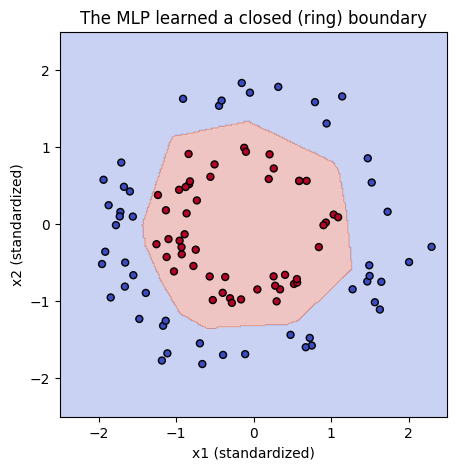

In [5]:
xx, yy = np.meshgrid(np.linspace(-2.5, 2.5, 300), np.linspace(-2.5, 2.5, 300))
grid = torch.tensor(np.c_[xx.ravel(), yy.ravel()], dtype=torch.float32)
with torch.no_grad():
    Z = model(grid).argmax(1).numpy().reshape(xx.shape)

plt.figure(figsize=(5, 5))
plt.contourf(xx, yy, Z, alpha=0.3, cmap="coolwarm")
plt.scatter(X_te_t[:, 0], X_te_t[:, 1], c=y_te, cmap="coolwarm", edgecolors="k", s=25)
plt.xlabel("x1 (standardized)"); plt.ylabel("x2 (standardized)")
plt.title("The MLP learned a closed (ring) boundary")
plt.show()

## Step 3: The Hidden Layer Is the Difference -- completion problem

Was it the hidden layer that did it, or just "more PyTorch"? Train a **linear** model -- one
`nn.Linear` straight from inputs to logits, with **no hidden layer and no activation** -- on the
same circles. Complete the output size (2 logits) and run it:

In [6]:
# Uncomment and complete: a LINEAR model has NO hidden layer and NO activation.
# torch.manual_seed(0)
# linear_model = nn.Sequential(nn.Linear(2, ____))    # 2 inputs straight to the logits -- no hidden layer
# opt = torch.optim.Adam(linear_model.parameters(), lr=0.05)
# for epoch in range(400):
#     opt.zero_grad()
#     loss_fn(linear_model(X_tr_t), y_tr_t).backward()
#     opt.step()
# with torch.no_grad():
#     acc = (linear_model(X_te_t).argmax(1) == y_te_t).float().mean().item()
# print(f"linear model (no hidden layer) test accuracy {acc:.3f}")

<details><summary>Expected Output</summary>

~~~text
linear model (no hidden layer) test accuracy 0.550
~~~

The blank is `nn.Linear(2, 2)`. With no hidden layer the model is a single linear classifier, and
it scores **0.550** -- barely above the coin flip -- because a straight line cannot wrap around a
ring. This is exactly L14's lesson, now *learned* rather than hand-wired: the nonlinear hidden
layer is what makes the difference, and gradient descent found the weights for us.
</details>

## Step 4: Universal Approximation

The reason MLPs are worth the trouble: a single hidden layer, given enough units, can approximate
**any** continuous function. Watch it happen -- fit `y = sin(3 pi x)` with a one-hidden-layer net
at three widths and read the final MSE:

In [7]:
xg = torch.linspace(-1, 1, 200).unsqueeze(1)
yg = torch.sin(3 * np.pi * xg)

fits = {}
for H in (1, 4, 16):
    torch.manual_seed(0)
    net = nn.Sequential(nn.Linear(1, H), nn.Tanh(), nn.Linear(H, 1))   # 1 -> H hidden -> 1
    opt = torch.optim.Adam(net.parameters(), lr=0.01)
    for _ in range(3000):
        opt.zero_grad()
        mse = nn.functional.mse_loss(net(xg), yg)
        mse.backward()
        opt.step()
    fits[H] = net
    print(f"hidden units H={H:2d}: final MSE {mse.item():.4f}")

hidden units H= 1: final MSE 0.4649


hidden units H= 4: final MSE 0.0153


hidden units H=16: final MSE 0.0002


~~~text
hidden units H= 1: final MSE 0.4649
hidden units H= 4: final MSE 0.0153
hidden units H=16: final MSE 0.0002
~~~

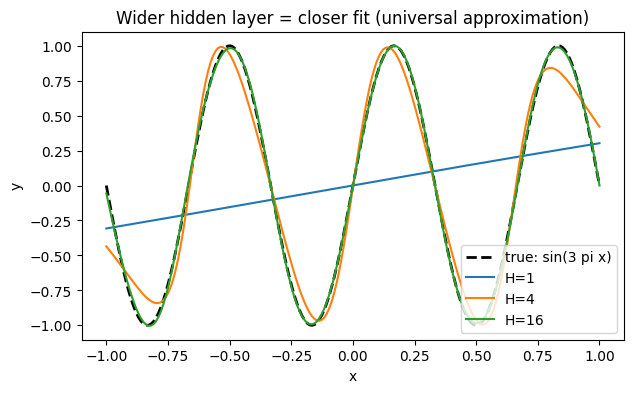

In [8]:
plt.figure(figsize=(7, 4))
plt.plot(xg, yg, "k--", linewidth=2, label="true: sin(3 pi x)")
for H, net in fits.items():
    with torch.no_grad():
        plt.plot(xg, net(xg), label=f"H={H}")
plt.legend(); plt.xlabel("x"); plt.ylabel("y")
plt.title("Wider hidden layer = closer fit (universal approximation)")
plt.show()

One hidden unit (`H=1`) can barely bend -- MSE 0.465. Four units already track the wave (0.0153),
and sixteen nail it (0.0002). More width buys a closer fit: that is universal approximation made
concrete. (It is an *existence* result -- it promises a fit exists, not that it is easy to find or
that one wide layer is the most efficient shape; depth usually is.)

## Your Turn

### Exercise 1 -- The capacity dial

Re-run the **circles** MLP from Steps 1-2 but shrink the hidden layer to a single unit
(`nn.Linear(2, 1)` then `nn.ReLU()` then `nn.Linear(1, 2)`), and compare its test accuracy to the
16-unit version. What does too little capacity do?

**Hint:** copy Step 1-2, change only the two hidden sizes to 1; keep `torch.manual_seed(0)`, Adam lr 0.05, 400 epochs.

In [9]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
hidden units H= 1: test accuracy 0.500
hidden units H=16: test accuracy 1.000
~~~

A single hidden unit cannot bend enough to wrap the ring, so it **underfits** to chance (0.500,
just like the linear model), while 16 units reach a perfect 1.000. Capacity is a dial: too few
units underfit; too many risk overfitting (L09). Sixteen is plenty here.
</details>

### Exercise 2 -- Swap the activation

Rebuild the 16-unit circles MLP with `nn.Tanh()` in place of `nn.ReLU()` (same training), and
report its test accuracy. Does the network still solve the circles?

**Hint:** copy Step 1-2, change `nn.ReLU()` to `nn.Tanh()`; keep `torch.manual_seed(0)`, Adam lr 0.05, 400 epochs.

In [10]:
# TODO: your code here

<details><summary>Expected Output</summary>

~~~text
Tanh hidden layer: test accuracy 1.000
~~~

Tanh reaches a perfect 1.000 too. The point is the *architecture* -- a hidden layer with **some**
nonlinear activation -- not one specific function. ReLU is the modern default (L14) for speed and
deep-network behavior, but the depth-plus-nonlinearity recipe is what carries the idea.
</details>

## Summary

- An **MLP** is a stack of dense layers with nonlinear activations: `nn.Sequential(nn.Linear,
  nn.ReLU, nn.Linear)`. Ours had 82 trainable parameters.
- The **four-step training loop** -- `zero_grad` -> forward -> loss -> `backward()` -> `step` --
  *learned* the weights; `loss.backward()` is the autograd black box (its mechanism is L16).
- A hidden layer let the MLP learn a **ring boundary** (test 1.000) that a linear model could not
  (0.550) -- L14's nonlinearity lesson, now learned by gradient descent instead of hand-wired.
- **Universal approximation:** a wider hidden layer fit the wiggly curve better (MSE 0.465 ->
  0.0153 -> 0.0002), and too few units underfit (Ex1: H=1 scores chance). Tanh worked as well as
  ReLU (Ex2) -- the architecture is the point.
- Next (L16): open the `backward()` black box -- the backpropagation algorithm that computes all
  those gradients.